In [3]:
# To run this script, you need a conda environment with GPU support
# Create and install with:
#
# conda install -c rapidsai -c nvidia -c conda-forge \
 #   cuml=23.08 python=3.10 cudatoolkit=11.8



import cupy as cp
import numpy as np
from cuml.feature_extraction.text import TfidfVectorizer
from cuml.metrics import pairwise_distances
import cudf as cd
from cudf import Series
import pandas as pd
import csv

from sklearn.manifold import SpectralEmbedding

from collections import defaultdict

from pathlib import Path

In [2]:

def compute_tf_idf_similarity(x):
    """
    Compute and return the pairwise (cosine) distances.
    """
    d = 1 - pairwise_distances(x, metric='cosine')
    return d



def vectorize_documents(documents):
    """
    Perform TF-IDF Vectorization of an input list of `documents`.

    Args:
        documents (list[str]) : The input list of documents to be vectorized
    """

    # Convert to cudf series
    documents = Series(documents)

    # Initialize TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(dtype=cp.float32)

    # Fit and transform the documents
    x = vectorizer.fit_transform(documents)

    return x

In [4]:
input_path = Path('data/raw_text/goose_CO')


df = pd.concat([pd.read_csv(f) 
                for f in input_path.iterdir() 
                if f.suffix.lower() == '.csv'])



In [5]:
x = vectorize_documents(df['text'])
x.shape

(2867, 24559)

In [13]:
sim_gpu = compute_tf_idf_similarity(x)
sim_cpu = cp.asnumpy(sim_gpu)

sim_cpu[sim_cpu<0.4]=0
np.savetxt('network_tfidf_adj.csv', sim_cpu, 
           fmt='%.10f', delimiter=' ')



In [ ]:
spectral_emb = SpectralEmbedding(n_components=2, affinity='precomputed')
x_emb = spectral_emb.fit_transform(sim_cpu)

/home/mauricio/miniconda3/envs/cuda/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)
/home/mauricio/miniconda3/envs/cuda/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
x_emb.shape

(2867, 2)

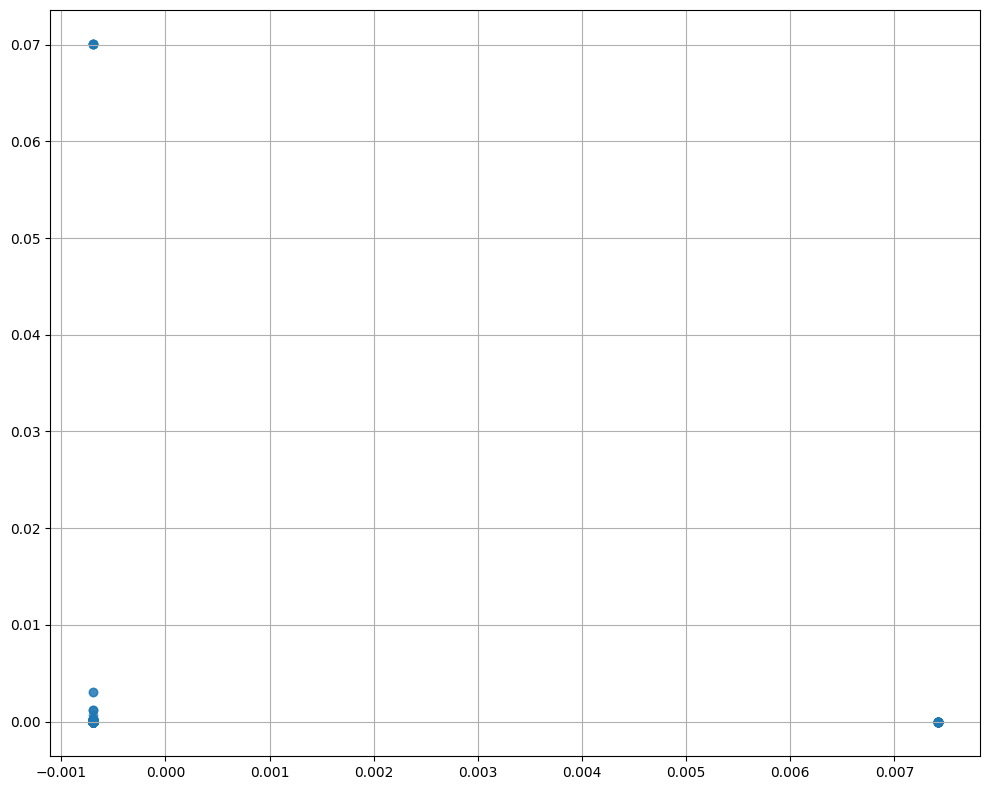

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(x_emb[:,0], x_emb[:,1], alpha=0.6)

plt.grid(True)
plt.tight_layout()